In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report

In [25]:
df = pd.read_csv('/content/customer_bookingg.csv', encoding='ISO-8859-1')
df.head(10)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
5,1,Internet,RoundTrip,3,48,20,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
6,3,Internet,RoundTrip,201,33,6,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
7,2,Internet,RoundTrip,238,19,14,Mon,AKLDEL,India,1,0,1,5.52,0
8,1,Internet,RoundTrip,80,22,4,Mon,AKLDEL,New Zealand,0,0,1,5.52,0
9,1,Mobile,RoundTrip,378,30,12,Sun,AKLDEL,India,0,0,0,5.52,0


In [26]:
df['flight_day'].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [19]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [23]:
print(df['booking_complete'].value_counts())

booking_complete
0    42522
1     7478
Name: count, dtype: int64


In [24]:
print(df['booking_complete'].value_counts(normalize=True).round(3))

booking_complete
0    0.85
1    0.15
Name: proportion, dtype: float64


feature engineering

In [28]:
#total extras
df['total_extras'] = (df['wants_extra_baggage'] + df['wants_preferred_seat'] + df['wants_in_flight_meals'])

#purchase lead buckets
def lead_bucket(days):
  if days <= 7:
    return 'last minute'
  elif days <= 30:
    return 'short notice'
  elif days <= 90:
    return 'planned'
  else:
     return 'far advanvce'
df['lead_bucket'] = df['purchase_lead'].apply(lead_bucket)

#convenient departure hour
df['is_convenient_hour'] = df['flight_hour'].between(6,21).astype(int)

#weekend departure
df['is_weekend'] = df['flight_day'].isin(['Sat','Sun']).astype(int)

#route popularity
df['route_popularity'] = df['route'].map(df['route'].value_counts())

#print the new columns
print(df[['total_extras', 'lead_bucket', 'is_convenient_hour', 'is_weekend', 'route_popularity']].head())

   total_extras   lead_bucket  is_convenient_hour  is_weekend  \
0             1  far advanvce                   1           1   
1             0  far advanvce                   0           1   
2             2  far advanvce                   1           0   
3             1  far advanvce                   0           1   
4             2       planned                   1           0   

   route_popularity  
0                20  
1                20  
2                20  
3                20  
4                20  


In [30]:
mapping = {'far advanvce':'far advance'}
df['lead_bucket'] = df['lead_bucket'].replace(mapping)

In [32]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,total_extras,lead_bucket,is_convenient_hour,is_weekend,route_popularity
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,1,far advance,1,1,20
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,0,far advance,0,1,20
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,2,far advance,1,0,20
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,1,far advance,0,1,20
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,2,planned,1,0,20


In [33]:
#encoding categorical columns
cat_cols = ['sales_channel','trip_type','flight_day','booking_origin','lead_bucket']

le = LabelEncoder()
for col in cat_cols:
  df[col + '_enc'] = le.fit_transform(df[col])

In [34]:
print(df[['sales_channel','sales_channel_enc','trip_type','trip_type_enc']].head(5))

  sales_channel  sales_channel_enc  trip_type  trip_type_enc
0      Internet                  0  RoundTrip              2
1      Internet                  0  RoundTrip              2
2      Internet                  0  RoundTrip              2
3      Internet                  0  RoundTrip              2
4      Internet                  0  RoundTrip              2


In [35]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,...,total_extras,lead_bucket,is_convenient_hour,is_weekend,route_popularity,sales_channel_enc,trip_type_enc,flight_day_enc,booking_origin_enc,lead_bucket_enc
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,...,1,far advance,1,1,20,0,2,2,61,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,...,0,far advance,0,1,20,0,2,2,61,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,...,2,far advance,1,0,20,0,2,6,36,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,...,1,far advance,0,1,20,0,2,2,61,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,...,2,planned,1,0,20,0,2,6,36,2


In [36]:
feature_cols = ['num_passengers','purchase_lead','length_of_stay','flight_hour','total_extras','is_convenient_hour','is_weekend','route_popularity',
                'sales_channel_enc','trip_type_enc','flight_day_enc','booking_origin_enc','lead_bucket_enc',
                'wants_extra_baggage','wants_preferred_seat','wants_in_flight_meals']
X = df[feature_cols]
y = df['booking_complete']

print('features shape: ', X.shape)
print('target shape: ', y.shape)

features shape:  (50000, 16)
target shape:  (50000,)


In [40]:
#random forest model
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=20, class_weight='balanced', random_state=42, n_jobs=-1)

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(rf, X, y, cv=cv, scoring=['accuracy','roc_auc','f1','precision','recall'], return_train_score=False)

In [43]:
print('5-fold Cross Validation Results')
metrics = {
    'Accuracy': cv_results['test_accuracy'],
    'ROC_AUC' : cv_results['test_roc_auc'],
    'F1_Score': cv_results['test_f1'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall']
}
for name, scores in metrics.items():
  print(f' {name:12s}: {scores.mean():.3f} (± {scores.std():.3f})')
cv_means = {k:v.mean() for k,v in metrics.items()}
cv_stds = {k:v.std() for k,v in metrics.items()}

5-fold Cross Validation Results
 Accuracy    : 0.703 (± 0.006)
 ROC_AUC     : 0.761 (± 0.004)
 F1_Score    : 0.409 (± 0.003)
 Precision   : 0.291 (± 0.003)
 Recall      : 0.688 (± 0.012)


In [45]:
#fit on full data
rf.fit(X, y)

feature_labels = [
    'Num passengers', 'Purchase lead (days)', 'Length of stay',
    'Flight hour', 'Total extras', 'Convenient hour', 'Weekend departure',
    'Route popularity',
    'Sales channel', 'Trip type', 'Flight day',
    'Booking origin', 'Lead bucket',
    'Wants extra baggage', 'Wants preferred seat', 'Wants in-flight meals',
]
importances = pd.Series(
    rf.feature_importances_,
    index=feature_labels
).sort_values()

print("\n Feature Importances (sorted)")
print(importances.round(4).to_string())


 Feature Importances (sorted)
Trip type                0.0024
Convenient hour          0.0069
Weekend departure        0.0071
Wants in-flight meals    0.0093
Wants preferred seat     0.0129
Num passengers           0.0149
Lead bucket              0.0161
Sales channel            0.0206
Wants extra baggage      0.0278
Flight day               0.0289
Total extras             0.0329
Flight hour              0.0486
Purchase lead (days)     0.0804
Length of stay           0.1217
Route popularity         0.1351
Booking origin           0.4344


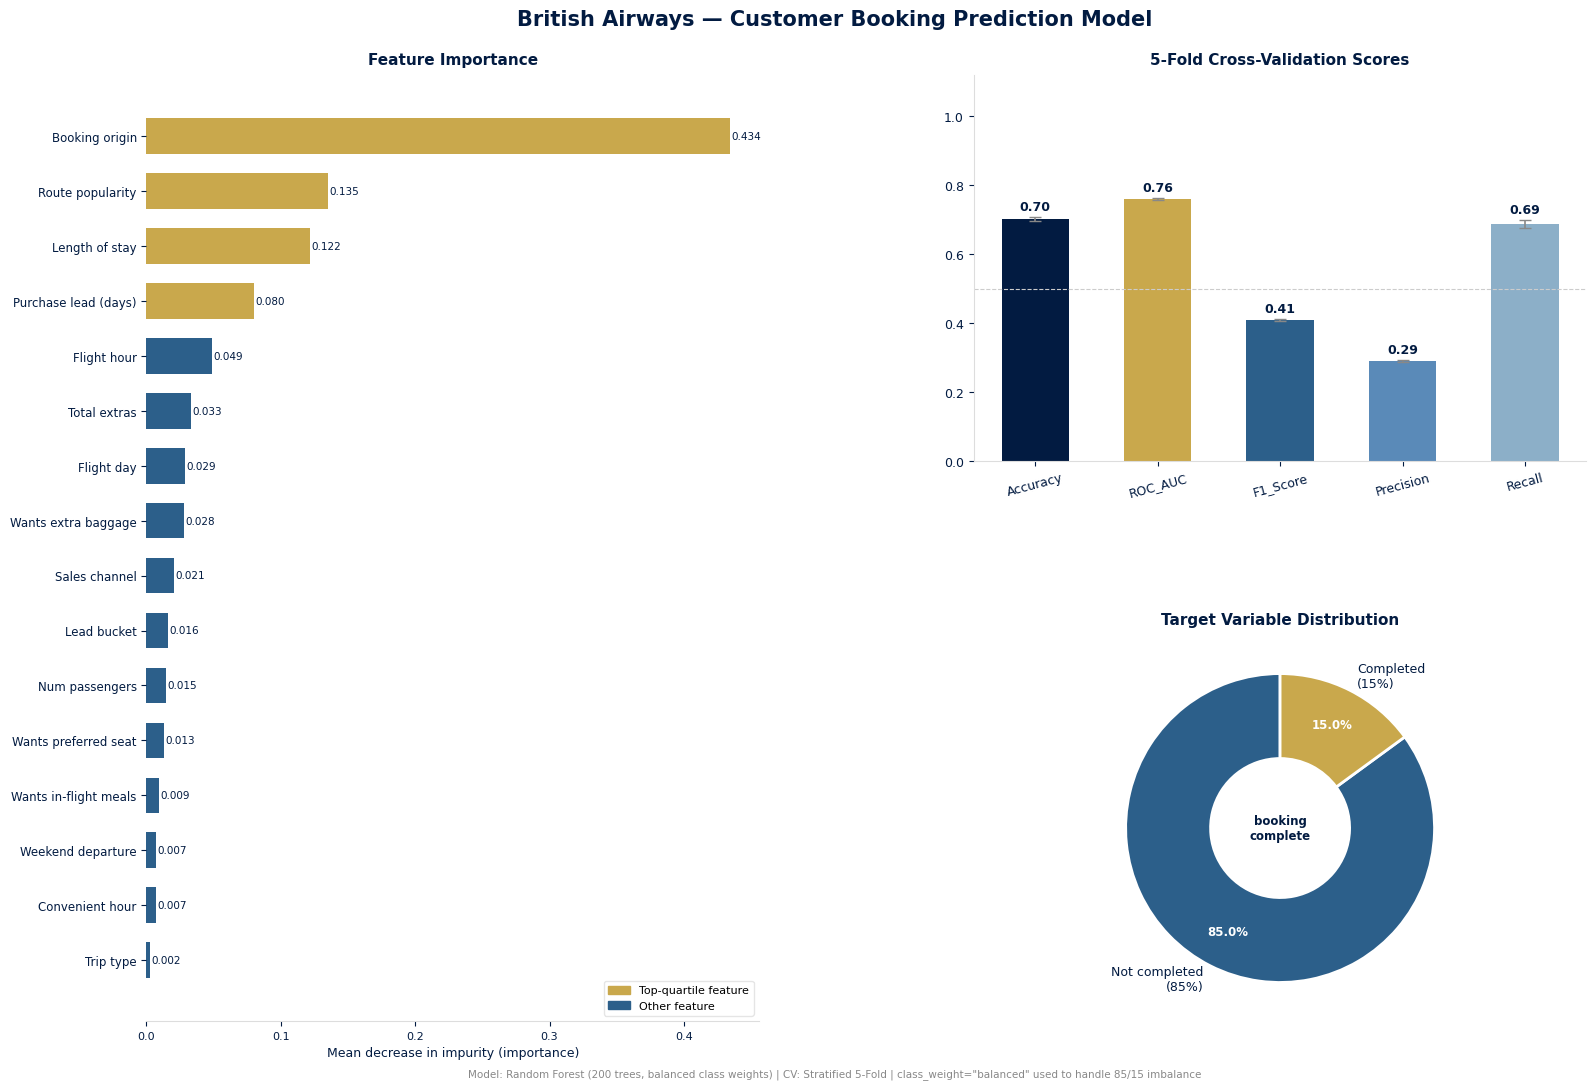


Done. Chart saved as ba_booking_model.png


In [53]:
BA_NAVY  = '#021B41'
BA_BLUE  = '#2C5F8A'
BA_GOLD  = '#C9A84C'
WHITE    = '#FFFFFF'

fig = plt.figure(figsize=(16, 11), facecolor=WHITE)
fig.suptitle('British Airways — Customer Booking Prediction Model',
             fontsize=15, fontweight='bold', color=BA_NAVY, y=0.98)

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35,
                      left=0.07, right=0.97, top=0.92, bottom=0.06)

# Panel A: Feature importance
ax1 = fig.add_subplot(gs[:, 0])

colors = [BA_GOLD if v >= importances.quantile(0.75) else BA_BLUE
          for v in importances.values]

bars = ax1.barh(importances.index, importances.values,
                color=colors, edgecolor='none', height=0.65)

ax1.set_xlabel('Mean decrease in impurity (importance)', fontsize=9, color=BA_NAVY)
ax1.set_title('Feature Importance', fontsize=11, fontweight='bold',
              color=BA_NAVY, pad=8)
ax1.tick_params(axis='y', labelsize=8.5, colors=BA_NAVY)
ax1.tick_params(axis='x', labelsize=8,   colors=BA_NAVY)
ax1.spines[['top','right', 'left']].set_visible(False)
ax1.spines['bottom'].set_color('#DDDDDD')
ax1.set_facecolor(WHITE)

for bar, val in zip(bars, importances.values):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=7.5, color=BA_NAVY)

top_patch  = mpatches.Patch(color=BA_GOLD, label='Top-quartile feature')
rest_patch = mpatches.Patch(color=BA_BLUE, label='Other feature')
ax1.legend(handles=[top_patch, rest_patch], fontsize=8,
           loc='lower right', framealpha=0.5)

#Panel B: CV metrics bar chart
ax2 = fig.add_subplot(gs[0, 1])

metric_names = list(cv_means.keys())
means  = list(cv_means.values())
stds   = list(cv_stds.values())
bar_colors = [BA_NAVY, BA_GOLD, BA_BLUE, '#5A8AB8', '#8CAFC8']

b2 = ax2.bar(metric_names, means, yerr=stds, color=bar_colors,
             edgecolor='none', capsize=4, width=0.55,
             error_kw={'elinewidth': 1.2, 'ecolor': '#888888'})

ax2.set_ylim(0, 1.12)
ax2.set_title('5-Fold Cross-Validation Scores', fontsize=11,
              fontweight='bold', color=BA_NAVY, pad=8)
ax2.tick_params(axis='x', labelsize=9, colors=BA_NAVY, rotation=15)
ax2.tick_params(axis='y', labelsize=9, colors=BA_NAVY)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#DDDDDD')
ax2.set_facecolor(WHITE)
ax2.axhline(0.5, color='#CCCCCC', linewidth=0.8, linestyle='--')

for bar, val, std in zip(b2, means, stds):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + std + 0.02,
             f'{val:.2f}', ha='center', fontsize=9, fontweight='bold',
             color=BA_NAVY)

#Panel C: Class imbalance doughnut
ax3 = fig.add_subplot(gs[1, 1])

counts = df['booking_complete'].value_counts().sort_index()
wedges, texts, autotexts = ax3.pie(
    counts.values,
    labels=['Not completed\n(85%)', 'Completed\n(15%)'],
    colors=[BA_BLUE, BA_GOLD],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=WHITE, linewidth=2)
)
for t in texts:
    t.set_fontsize(9);  t.set_color(BA_NAVY)
for at in autotexts:
    at.set_fontsize(8.5); at.set_color(WHITE); at.set_fontweight('bold')

ax3.set_title('Target Variable Distribution', fontsize=11,
              fontweight='bold', color=BA_NAVY, pad=8)
ax3.text(0, 0, 'booking\ncomplete', ha='center', va='center',
         fontsize=8.5, color=BA_NAVY, fontweight='bold')

fig.text(0.5, 0.01,
         'Model: Random Forest (200 trees, balanced class weights) | '
         'CV: Stratified 5-Fold | '
         'class_weight="balanced" used to handle 85/15 imbalance',
         ha='center', fontsize=7.5, color='#888888')

plt.savefig('ba_booking_model.png', dpi=160, bbox_inches='tight', facecolor=WHITE)
plt.show()
print("\nDone. Chart saved as ba_booking_model.png")